# Census Income Classification Model

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

## Part 1: Choose Data Set and Build DataFrame

**Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. This will be used to predict whether an individual's annual income exceeds $50,000. The label column is `income_binary`, which contains two values: `<=50K` and `>50K`.

In [ ]:
# File paths for data set
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")

# Load dataset and save it to df
df = pd.read_csv(census_filename)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define ML Problem

For the Census income dataset, I am planning to use these features: education, marital-status, occupation, race, sex_selfID, hours_per_week, and native-country. This dataset is essential because according to the [United States Census Bureau](https://www.census.gov/acs/www/about/why-we-ask-each-question/income/), income data is used to determine how much of federal funding is allocated to states and communities in the United States.

## Part 3: Understanding Data



### Class Imbalance


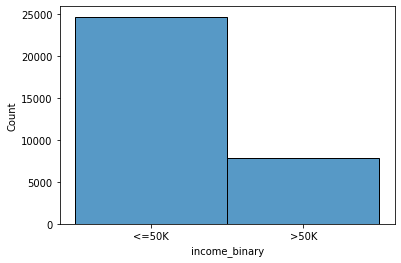

In [ ]:
sns.histplot(df["income_binary"]);

### Inspect and Analyze Data

In [ ]:
print(f"NA Values:\n{df.isnull().sum()}")
print()
print(f"Duplicated Values:\n{df.duplicated().sum()}")
print()
print(f"Data Types:\n{df.dtypes}")
print()
print(f"Rows and Columns:\n{df.shape}")

NA Values:
age                162
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week     325
native-country     583
income_binary        0
dtype: int64

Duplicated Values:
22

Data Types:
age               float64
workclass          object
fnlwgt              int64
education          object
education-num       int64
marital-status     object
occupation         object
relationship       object
race               object
sex_selfID         object
capital-gain        int64
capital-loss        int64
hours-per-week    float64
native-country     object
income_binary      object
dtype: object

Rows and Columns:
(32561, 15)


In [5]:
print("Summary Statistics")
df.describe(include="all")

Summary Statistics


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
count,32399.000000,30725,3.256100e+04,32561,32561.000000,32561,30718,32561,32561,32561,32561.000000,32561.000000,32236.000000,31978,32561
unique,NaN,8,NaN,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Non-Female,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.589216,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,615.907773,87.303830,40.450428,NaN,NaN
std,13.647862,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,2420.191974,402.960219,12.353748,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [6]:
# Check the Number of Rows With No NA Values
print(f"Number of Rows With No NA Values: {df.dropna().shape[0]}") # 29716

Number of Rows With No NA Values: 29716


In [7]:
# Searching for Outliers Using Z-scores
z_scores = df.select_dtypes(include=["number"]).apply(stats.zscore)
outliers = abs(z_scores) >= 3
z_scores[outliers.any(axis=1)]

print(f"Columns With Outlier Values: {list(outliers.any(axis=0)[1:5].index)}")
print(f"Total Number of Rows With Outlier Values: {z_scores[outliers.any(axis=1)].shape[0]}")

Columns With Outlier Values: ['fnlwgt', 'education-num', 'capital-gain', 'capital-loss']
Total Number of Rows With Outlier Values: 2861


In [8]:
# Shows Which Number in education-num Corresponds With Which Education Level
df.groupby("education-num")["education"].unique()

education-num
1        [Preschool]
2          [1st-4th]
3          [5th-6th]
4          [7th-8th]
5              [9th]
6             [10th]
7             [11th]
8             [12th]
9          [HS-grad]
10    [Some-college]
11       [Assoc-voc]
12      [Assoc-acdm]
13       [Bachelors]
14         [Masters]
15     [Prof-school]
16       [Doctorate]
Name: education, dtype: object

In [9]:
print(f"99.9th Percentile of Capital Gain: {np.percentile(df['capital-gain'], 99.9)}")
print(f"99th Percentile of Capital Gain: {np.percentile(df['capital-gain'], 99.0)}")
print(f"95th Percentile of Capital Gain: {np.percentile(df['capital-gain'], 95.0)}")
print(f"90th Percentile of Capital Gain: {np.percentile(df['capital-gain'], 90.0)}")

99.9th Percentile of Capital Gain: 14084.0
99th Percentile of Capital Gain: 14084.0
95th Percentile of Capital Gain: 5013.0
90th Percentile of Capital Gain: 0.0


In [10]:
print(f"99.9th Percentile of Capital Loss: {np.percentile(df['capital-loss'], 99.9)}")
print(f"99th Percentile of Capital Loss: {np.percentile(df['capital-loss'], 99.0)}")
print(f"95th Percentile of Capital Loss: {np.percentile(df['capital-loss'], 95.0)}")
print(f"90th Percentile of Capital Loss: {np.percentile(df['capital-loss'], 90.0)}")

99.9th Percentile of Capital Loss: 2559.0
99th Percentile of Capital Loss: 1980.0
95th Percentile of Capital Loss: 0.0
90th Percentile of Capital Loss: 0.0


In [11]:
# Exploring Capital Gain and Capital Loss Columns
print(f"Capital Gain Top Five Most Frequent Values:\n {df['capital-gain'].value_counts()[0:5]}")
print(f"Capital Loss Top Five Most Frequent Values:\n {df['capital-loss'].value_counts()[0:5]}")

Capital Gain Top Five Most Frequent Values:
 0        29849
14084      680
7688       284
7298       246
3103        97
Name: capital-gain, dtype: int64
Capital Loss Top Five Most Frequent Values:
 0       31042
1902      202
1977      168
1887      159
1848       51
Name: capital-loss, dtype: int64


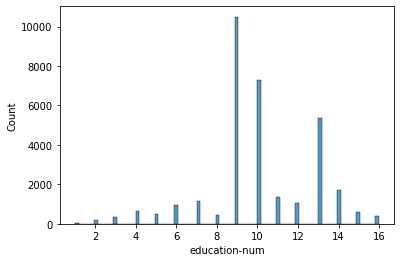

In [12]:
# Showing the Distribution of Cne of the Outlier Columns
sns.histplot(df["education-num"]);

In [13]:
# Tranforming the Label Column into a Binary Column in a Copied Dataset
le = LabelEncoder()
df_copy = df.copy()
le.fit(df_copy["income_binary"])
df_copy["income_encoded"] = le.transform(df_copy["income_binary"])

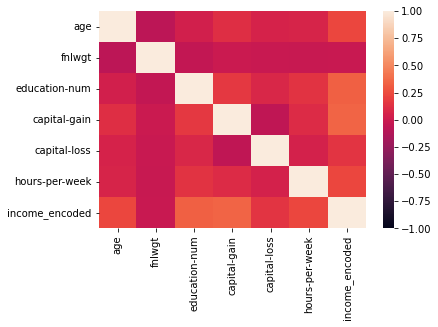

In [14]:
corr = df_copy.select_dtypes(include=["number"]).corr()
sns.heatmap(corr, vmin=-1, vmax=1);

In [15]:
# Categorical/Object Columns
df.select_dtypes(include=["object"]).head()

,workclass,education,marital-status,occupation,relationship,race,sex_selfID,native-country,income_binary
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Non-Female,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


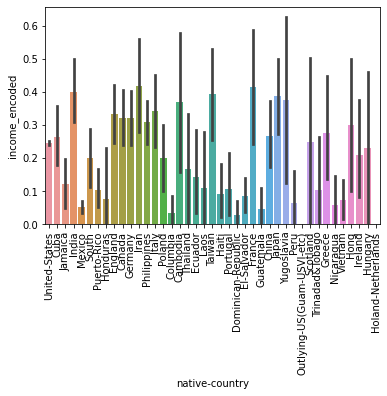

In [16]:
# Relationship Between native-country and income-encoded
sns.barplot(x=df_copy["native-country"], y=df_copy["income_encoded"])
plt.xticks(rotation=90)
plt.show()

In [17]:
# Comparing the Unique Values of Relationship vs Marital Status
print(f"Unique Values in Relationship: {df['relationship'].unique()}")
print()
print(f"Unique Values in Marital Status: {df['marital-status'].unique()}")

Unique Values in Relationship: ['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']

Unique Values in Marital Status: ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']


### EDA Summary

The Census Income Dataset has 22 duplicate records as well as 5 columns and 2845 rows with missing values. Because the missing values only make up 8.74% of the total number of records, it is reasonable to drop the records with these missing values. Additionally, there are four columns with outliers: fnlwgt, education-num, capital-gain, and capital-loss. But, fnlwgt is an irrelavant column that will need to be dropped and education-num is an ordinal column where each number represents a different level of education. As such, only capital-gain and capital-loss needs to be windsorized, likely with a top and bottom 1% cap. However, this windsorization may not work on capital-gain as the vast majority of its values are 0 and the values at the 99.9th and 99th percentiles are both 14084. The heatmap shows that education-num and capital-gain have the strongest relationship with income_encoded or income_binary out of all the numeric columns. On the other hand, fnlwgt has the weakest relationship with income_binary, further solidying that this column should be dropped as a feature. The class inbalance can be addressed by adding weights to the models. Class 1 or greater than 50K income would have a higher weight since it is the minority class. When the model makes a mistake when predicting this class, it would be penalized more.

### Ethical Considerations:

1. This Census dataset uses protected characteristics like age, sex, race, and military status. Any significant imbalance within these protected charactertistics can create bias that usually puts minority groups at a disadvantage. Additionally, the native country column can be used as a proxy for race and ethnicity. There are also crucial characteristics missing including disability, gender identity, and religion. Without information of these important characteristics, even a high-performing model cannot accuractely predicts which groups are more likely to earn more, equal to, or less than 50K. 
2. Minority groups are most likely to be harmed by a model that makes incorrect predictions. This includes women, people over 40 years old, as well as ethnic and racial minorities such as people identified as Black, Asian, American Indian, or Latino. Since the Census income data is used to determine who needs economic assistance, any mistakes by a poorly trained and evaluated model may result in these groups being provided less resources than they need.

Sources Used:

[What are some ethical challenges associated with using specific datasets?](https://milvus.io/ai-quick-reference/what-are-some-ethical-challenges-associated-with-using-specific-datasets)

[Ohio State University Civil Rights Compliance Office](https://civilrights.osu.edu/training-and-education/protected-class-definitions)

[Why We Ask Questions About Income](https://www.census.gov/acs/www/about/why-we-ask-each-question/income/)

[Ethnic and Racial Minorities & Socioeconomic Status](https://www.apa.org/pi/ses/resources/publications/minorities)

## Part 4: Prepare Your Data

In [18]:
# Drop Rows with Null Values
df_clean = df.copy()

df_clean = df_clean.dropna() # From 32,561 to 29,716 rows

In [19]:
# Drop Duplicate Rows
df_clean = df_clean.drop_duplicates() # From 29,716 to 29,694 rows

In [20]:
# Drop Irrelevant or Redundant Columns
df_clean = df_clean.drop(columns="fnlwgt") # Irrelevant
df_clean = df_clean.drop(columns="relationship") # Redundant with Marital Status
df_clean = df_clean.drop(columns="education") # Redundant with education-num

In [21]:
# Deal With Columns That Have Outliers
df_clean["capital-gain"] = stats.mstats.winsorize(df_clean['capital-gain'], limits=[0.01, 0.01])
df_clean["capital-loss"] = stats.mstats.winsorize(df_clean['capital-loss'], limits=[0.01, 0.01])

In [22]:
# Find the Number of Unique Values Within Each Categorical Column
for column in list(df_clean.select_dtypes(include=["object"]).columns):
    print(f"{column}: {df[column].nunique()}")

workclass: 8
marital-status: 7
occupation: 14
race: 5
sex_selfID: 2
native-country: 41
income_binary: 2


In [23]:
# One-hot Encode Categorical Columns
for categorical_column in df_clean[["workclass", "marital-status", "occupation", "race", "sex_selfID"]]:
    dummy_columns = pd.get_dummies(df_clean[categorical_column], prefix=categorical_column)
    df_clean = df_clean.join(dummy_columns) # Join One-hot Encoded to df_clean
    df_clean.drop(columns=categorical_column, inplace=True) # Replace Original Column

In [24]:
# Find the Top 10 Native Countries
top10_native_countries = df_clean["native-country"].value_counts()[0:10]
top10_native_countries

United-States    27086
Mexico             600
Philippines        184
Germany            127
Puerto-Rico        107
Canada             105
India               98
El-Salvador         98
Cuba                92
England             82
Name: native-country, dtype: int64

In [25]:
# One-hot Encoding the Top 10 Native Countries
for value in top10_native_countries.index:
    df_clean["native_country_"+value] = np.where(df_clean["native-country"]==value, 1, 0)

In [26]:
# Include the Rest of the Native Countries That Are Not Part of the Top 10
other_native_countries = df_clean["native-country"].value_counts()[10:]

In [27]:
df_clean["native_country_Other"] = np.where(df_clean["native-country"].isin(other_native_countries.index), 1, 0)

In [28]:
# Dropping Original native-country column
df_clean.drop(columns="native-country", inplace=True)

In [29]:
# Label Encoding the income_binary column
le = LabelEncoder()
le.fit(df_clean["income_binary"])
df_clean["income_encoded"] = le.transform(df_clean['income_binary'])

In [30]:
# Shows Which Number Corresponds With Which Income Class
df_clean.groupby("income_encoded")["income_binary"].unique()

income_encoded
0    [<=50K]
1     [>50K]
Name: income_binary, dtype: object

In [31]:
# Drop the Original income_binary column
df_clean.drop(columns="income_binary", inplace=True)

### Data Preparation Summary:

1. I dropped all of the duplicate and missing values. This was a feasible option because null values only made up 8.74% of the original dataset and duplicates only made up 0.68% of the original dataset. 
2. I dropped irrelevant or redundant columns: fnlwgt, relationship, and education. fnlwgt is an irrelevant column. On the other hand, relationship is redundant with marital status and education is redundant with education-num. 
3. I applied windsorization to the outlier columns, capital-gain and capital-loss. During exploratory data analysis, I computed the z-scores of the numerical columns to find these outliers. 
4. Next, I one-hot encoded the categorical columns. There were too many values in native-country, so I only found the top 10 native countries and then one-hot encoded the column. This step was crucial because the model cannot process categorical data.
5. Finally, I label encoded the income-binary column to transform the two categories, <=50K and >50K, to 0 and 1. I did this for the same reason I one-hot encoded the feature columns.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

In [32]:
# Create labeled examples from the dataset
X = df_clean.drop(columns="income_encoded")
y = df_clean["income_encoded"]

In [33]:
# Create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1234)

In [34]:
# Scaling X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Scaling X_test
X_test_scaled = scaler.transform(X_test)

In [35]:
# Train, test and evaluate your model
model = LogisticRegression(C=1, max_iter=100)

model.fit(X_train_scaled, y_train)

probability_predictions = model.predict_proba(X_test_scaled)

l_loss = log_loss(y_test, probability_predictions)
print(f"Log Loss: {l_loss}")

class_label_predictions = model.predict(X_test_scaled)

acc_score = accuracy_score(y_test, class_label_predictions)
print(f"Accuracy Score: {acc_score}")

f_score = f1_score(y_test, class_label_predictions, average="binary")
print(f"F1 Score: {f_score}")

Log Loss: 0.34101063382338265
Accuracy Score: 0.8403061224489796
F1 Score: 0.6549062844542447


In [36]:
# Create Weights Logistic Regression Model
weights = {0:1, 1:10} # Class 1 (Minority Class) = >50K

weighted_model = LogisticRegression(C=1, max_iter=100, class_weight=weights)

weighted_model.fit(X_train_scaled, y_train)

weighted_probability_predictions = weighted_model.predict_proba(X_test_scaled)

weighted_loss = log_loss(y_test, weighted_probability_predictions)
print(f"Weighted Model Log Loss: {weighted_loss}")

weighted_label_predictions = weighted_model.predict(X_test_scaled)

weighted_acc = accuracy_score(y_test, weighted_label_predictions)
print(f"Weighted Model Accuracy Score: {weighted_acc}")

weighted_f = f1_score(y_test, weighted_label_predictions, average="binary")
print(f"Weighted Model F1 Score: {weighted_f}")

Weighted Model Log Loss: 0.6292784952922108
Weighted Model Accuracy Score: 0.7120408163265306
Weighted Model F1 Score: 0.6271141649048625


In [37]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
param_grid = {
    "C":[0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "class_weight":[None, "balanced", {0:1, 1:5}, {0:1, 1:10}]
}

grid = GridSearchCV(weighted_model, param_grid, cv=5, scoring="f1")

grid_search = grid.fit(X_train_scaled, y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}") 

Best Hyperparameters: {'C': 1, 'class_weight': 'balanced'}


In [38]:
# Use Optimal Hyperparameters
weighted_model = LogisticRegression(C=10, max_iter=100, class_weight="balanced")

weighted_model.fit(X_train_scaled, y_train)

weighted_probability_predictions = weighted_model.predict_proba(X_test_scaled)

weighted_loss = log_loss(y_test, weighted_probability_predictions)
print(f"Weighted Model Log Loss With Optimal Hyperparameters: {weighted_loss}")

weighted_label_predictions = weighted_model.predict(X_test_scaled)

weighted_acc = accuracy_score(y_test, weighted_label_predictions)
print(f"Weighted Model Accuracy Score With Optimal Hyperparameters: {weighted_acc}")

weighted_f = f1_score(y_test, weighted_label_predictions, average="binary")
print(f"Weighted Model F1 Score With Optimal Hyperparameters: {weighted_f}")

Weighted Model Log Loss With Optimal Hyperparameters: 0.4032812875211753
Weighted Model Accuracy Score With Optimal Hyperparameters: 0.8075510204081633
Weighted Model F1 Score With Optimal Hyperparameters: 0.6855618539513172


In [39]:
# Creating Coefficient Table
coef_table = pd.DataFrame({
    "Features":X.columns,
    "Coefficients":model.coef_[0]
})

coef_table = coef_table.sort_values(by="Coefficients", ascending=False)

In [40]:
# Top 10 Coefficients
top10_coef = coef_table[0:10]
print(f"Top Ten Coefficients:\n {top10_coef}")

Top Ten Coefficients:
                              Features  Coefficients
2                        capital-gain      0.868591
14  marital-status_Married-civ-spouse      0.783590
1                       education-num      0.709244
4                      hours-per-week      0.353782
0                                 age      0.341822
22         occupation_Exec-managerial      0.266412
3                        capital-loss      0.266078
28          occupation_Prof-specialty      0.193484
31            occupation_Tech-support      0.111711
5               workclass_Federal-gov      0.107868


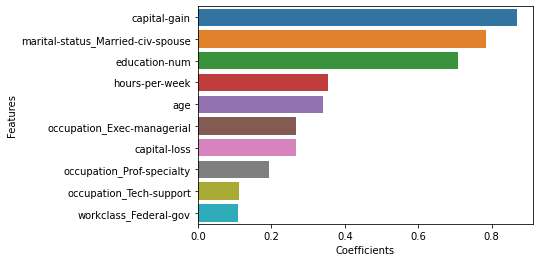

In [41]:
# Top 10 Coefficients Plotted in Bargraph
sns.barplot(x = top10_coef["Coefficients"], y = top10_coef["Features"]);

### Model Reflection:

1. I chose the Logistic Regression model. It is an efficient model to use for binary classification problems like predicting which income group an individual is based on their characteristics. Additionally, the output of Logistic Regression models are easy to interpret. They output model coefficients which show that the larger the coefficient the stronger the relationship that particular feature has with the label. 
2. Through the model selection process, I improved my understanding of which evaluation techniques are suitable for which models. For example, accuracy, f1 score, and log loss are usually practical ways to evaluate the performance of a Logistic Regression model.
3. As mentioned before, accuracy, f1 score, and log loss are normally practical ways to evaluate a Logistic Regression model. However, during this step, I learned that for an imbalanced dataset, the f1 score was the most reliable evaluation method. As such, while my final weighted model with the optimal hyperparameters had less-than-ideal accuracy and log loss scores, it had the highest f1 score. As previously stated, the coefficients signify how strong the relationship is between each feature and the label. My model shows that capital-gain with a coefficient value of 0.868583 has the strongest relationship with the label.  
4. People whose native country is not the United States are more likely to be harmed by this model's incorrect predictions. In the original dataset, people whose native country was the United States made up 91.22% of the dataset, meaning that the model likely has a far better understanding of the relationship between U.S. native country and the label data. 

Sources Used:

[Advantages and Disadvantages of Logistic Regression](https://www.geeksforgeeks.org/data-science/advantages-and-disadvantages-of-logistic-regression/)

[F1 Score in Machine Learning](https://www.geeksforgeeks.org/machine-learning/f1-score-in-machine-learning/)

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

### Step 1: Define Model Architecture

In [ ]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
input_layer = keras.layers.InputLayer(input_shape=n_features)
nn_model.add(input_layer)

# Create the hidden layers and add the hidden layers to the 'nn_model' object
hidden_layer_1 = keras.layers.Dense(units=64, activation="relu", name="hidden_layer_1")
nn_model.add(hidden_layer_1)

hidden_layer_2 = keras.layers.Dense(units=32, activation="relu", name="hidden_layer_2")
nn_model.add(hidden_layer_2)

hidden_layer_3 = keras.layers.Dense(units=16, activation="relu", name="hidden_layer_3")
nn_model.add(hidden_layer_3)

# I created three hidden layers with 64, 32, and 16 neurons. 
# I used this structure because it is complex enough for the model to learn and understand the complex relationships between factors that ultimately correlate with either income equal to or less than 50K and income greater than 50K without being at a high risk of overfitting.

# Create the output layer and add the output layer to the 'nn_model' object
output_layer = keras.layers.Dense(units=1, activation="sigmoid", name="output")
nn_model.add(output_layer)

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
hidden_layer_1 (Dense)       (None, 64)                3328      
_________________________________________________________________
hidden_layer_2 (Dense)       (None, 32)                2080      
_________________________________________________________________
hidden_layer_3 (Dense)       (None, 16)                528       
_________________________________________________________________
output (Dense)               (None, 1)                 17        
Total params: 5,953
Trainable params: 5,953
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

In [ ]:
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.1)

Having a learning rate of 0.1 prevents the optimizer from taking steps that are too big that may result in them skipping over the minimum of the loss functions of the training points.

However, having a learning rate of 0.1 still ensures that the optimizer is making steady progress towards finding the minimum without taking too much time.

### Step 3: Define the Loss Function

In [45]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

In [ ]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=["accuracy"])

### Step 5: Fit the Model to the Training Data

In [47]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


In [ ]:
t0 = time.time() # start time

num_epochs = 15
# Training the model 100 times would allow the model to understand the general patterns within the dataset without memorizing the data and outputting a misleading high evaluation scores.

weights = {0:1, 1:3}

history = nn_model.fit(
    X_train_scaled, 
    y_train,
    epochs=num_epochs,
    verbose=0,
    validation_split=0.2,
    class_weight=weights,
    callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=10)]
)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [10/ 15], Loss: 0.5112, Accuracy: 0.8216, Val_loss: 0.3857, Val_accuracy: 0.8183
Elapsed time: 31.25s


### Step 6: Visualize Training Performance



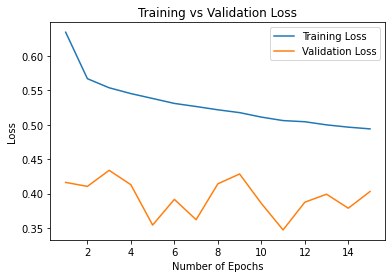

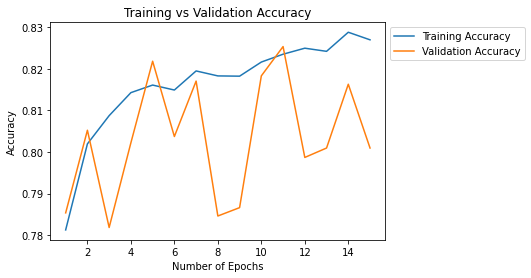

In [ ]:
# Plot training loss and validation loss over epochs
plt.plot(range(1, num_epochs + 1), history.history["loss"], label="Training Loss")
plt.plot(range(1, num_epochs + 1), history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Number of Epochs")
plt.ylabel("Loss")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

# Plot training accuracy and validation accuracy over epochs
plt.plot(range(1, num_epochs + 1), history.history["accuracy"], label="Training Accuracy")
plt.plot(range(1, num_epochs + 1), history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Number of Epochs")
plt.ylabel("Accuracy")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

In [ ]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

neural_probabilities = nn_model.predict(X_test_scaled).flatten()

neural_binary_labels = []
for probability in neural_probabilities:
    if probability >= 0.5:
        label = 1
    else:
        label = 0
    neural_binary_labels.append(label)


In [ ]:
# Compute accuracy and F1 score for the neural network and print the results

neural_acc = accuracy_score(y_test, neural_binary_labels)
print(f"Neural Network Accuracy Score: {neural_acc}")

neural_f = f1_score(y_test, neural_binary_labels, average="binary")
print(f"Neural Network F1 Score: {neural_f}")

Neural Network Accuracy Score: 0.7948979591836735
Neural Network F1 Score: 0.6811548223350253


#### Neural Network Reflection:

1. In my model, I created three hidden layers with 64, 32, and 16 units. This allows the model to be complex enough to understand the nuanced relationships between the features and the label without the high risk of overfitting. Each of the hidden layers use the ReLu activation function. ReLu is the ideal activation function to use for hidden layers because large positive or negative outputs do not result in tiny gradients unlike with the sigmoid and hyperbolic tangent activation functions. On the other hand, the output layer uses the sigmoid activation function. While the sigmoid activation function is not ideal for hidden layers, it works well with an output layer of a model that is solving a binary classification problem because it outputs either 0 or 1. I also trained the model on 15 epochs. Initially I trained my model on 100 epochs, however, that lead to severe overfitting. 
2. The training curves tell me that the loss was the lowest at 15 epochs and accuracy was the highest at 14 epochs. As mentioned before, when I had trained my model with 100 epochs, there was severe overfitting. I could tell because while my model reported increasingly higher losses on its validation set, it reported increasingly smaller losses on its training set. Simply reducing the number of epochs to 15 solved this issue. 
3. The neural network performed similarily to the logistic regression model. It had an accuracy score of 0.79 and a f1 score of 0.68. I was not surprised by the result of the accuracy score because it is similar to the accuracy scores when the training and valdation sets were used.

## Part 7: Compare Your Models and Reflect

###  Results Summary

In [52]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))
#
# YOUR CODE HERE
results = pd.DataFrame({
    "Metric": ["Accuracy", "F1 Score"],
    "Logistic Regression Model": [weighted_acc, weighted_f],
    "Neural Network": [neural_acc, neural_f]
})

print(results.to_string(index=False))

   Metric  Logistic Regression Model  Neural Network
 Accuracy                   0.807551        0.794898
 F1 Score                   0.685562        0.681155


### Comparative Analysis

1. The two models performed almost the same as each other. However, the neural network performed slighly worse. While the Logistic Regression model has an accuracy score of 0.81 and a f1 score of 0.69, the neural network has an accuracy score of 0.79 and a f1 score of 0.68. 
2. The neural network in this instance was not justified because it did not perform significantly better than the Logistic Regression model.
3. I would recommend deploying the Logistic Regression model. It doesn't have the same complexity of a neural network, but performs slighly better. Because the model is weighted, it is able to handle imbalanced datasets. Additionally, its coefficients are easy to interpret even by people who only have a basic understanding of data and statistics. 
4. I would take the time to create more models and compare their f1 scores with each other. While the Logistic Regression model performed well, there may be other model types that work even better with this kind of dataset. 

---
## AI Use Attestation

1. I used ChatGPT throughout this project for a few different reasons. I used it to evaluate the quality of my code and help me understand where I made a mistake if I had gotten an error. Additionally, I used it to brainstorm which model may be the best to use for this project. Furthermore, I used it to evaluate my interpretation of my visualizations, especially when my loss graph which showed that my neural network was overfitting when training with 100 epochs.
2. The data preparation portion of the project required the most effort. I had to review several of our past assignments to relearn functions and processes like one-hot encoding and windsorization. 
3. I verified my work was correct with the support of ChatGPT. I provided ChatGPT with my interpretation of what the code was doing and asked it to evaluate my understanding of the code. This allowed me to identified any issues with my code and fix it.
4. Next time, I would use ChatGPT more for brainstorming. Many of my issues when approaching this project came from a lack of understanding of the direction I wanted to take. Because of this, my EDA was initially shallow and my data preparation had missed critical steps that would have negatively affected the models had I left it that way.